# Deepweeds - EfficientnetV2B0

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2026-02-16 08:08:18.919497: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-16 08:08:18.919607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-16 08:08:19.042382: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = False
K_FOLD_INDEX = 1
oversampling = 0 # How many times are we gonna over sample

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
IMG_SIZE=(224,224,3)

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

## Subspace_Bottleneck_FCLayer Config - for Experiment #.5
NUM_SPACES = 16
FINAL_FEAT_SIZE = 1280

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = False
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### Base Model Freezing Part
INIT_LR2 = 2e-5 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-3 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 2 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  676  637  619  613  637  605  644  610  5463 	Total: (10504, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1822 	Total: (3502, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  205  213  202  215  203  1821 	Total: (3503, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10504 files belonging to 9 classes.
Found 3502 files belonging to 9 classes.
Found 3503 files belonging to 9 classes.


# Sample Images

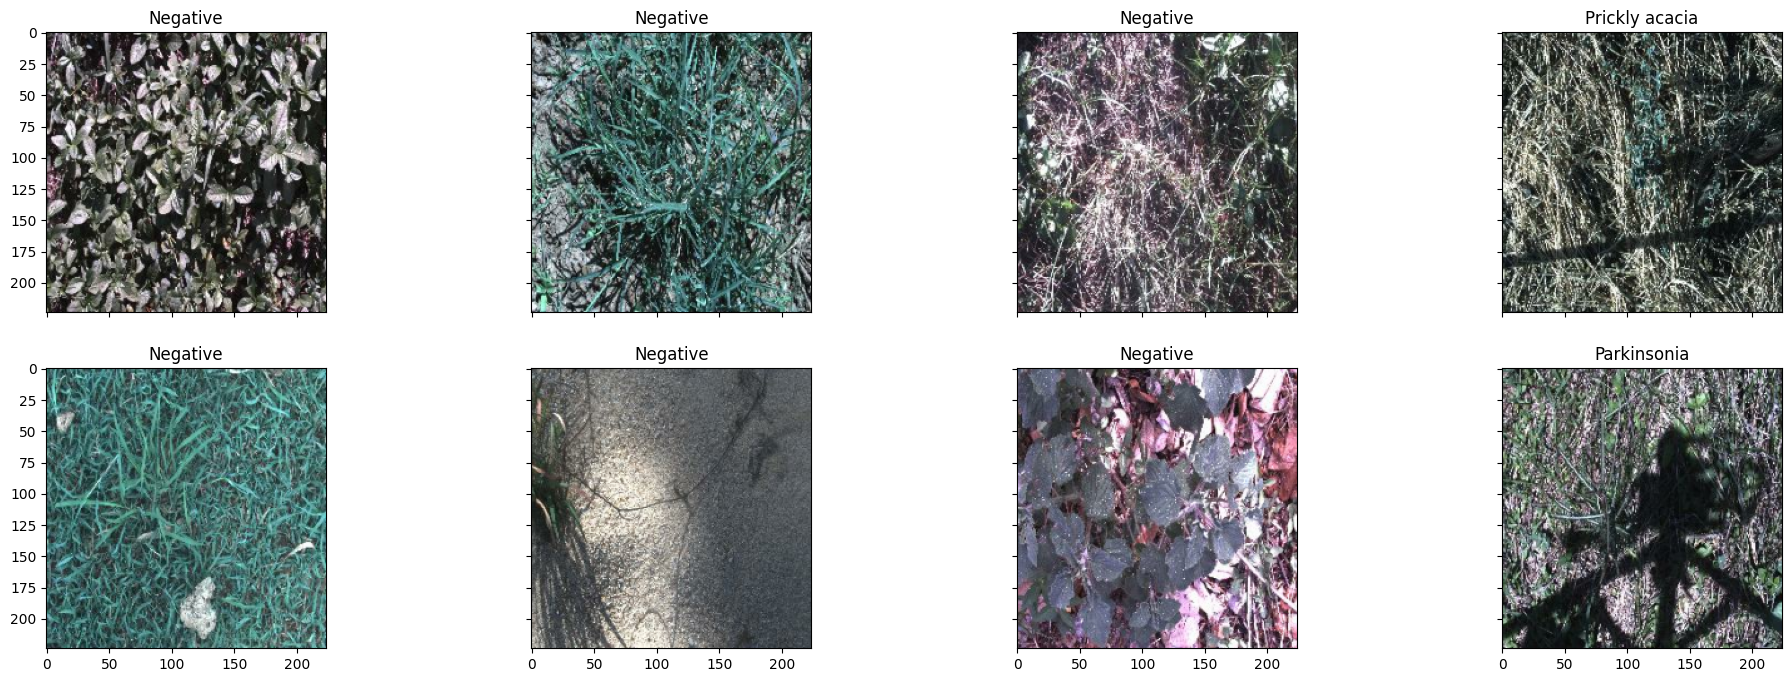

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# ConvSelfAt10tion

In [18]:
class TiledUpSampler2D(tf.keras.layers.Layer):
    def __init__(self, **kwargs): ## pooling method: avg | max
        super().__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 4 ## asserting the input shape is [batch_size, height, width, channel]
        super().build(input_shape)

    def call(self, x):
        shape = x.shape

        pad = shape[2]//2
        t = shape[2] - pad
        w = shape[2] + (2*pad)
        h = shape[1]
        
        _x = tf.tile(x,tf.constant([1,1,3,1]))
        _x = tf.image.crop_to_bounding_box(_x, 0, t, h, w)

        pad = shape[1]//2
        h = shape[1] + (2*pad)
        t = shape[1] - pad
        _x = tf.tile(_x,tf.constant([1,3,1,1]))
        _x = tf.image.crop_to_bounding_box(_x, t, 0, h, w)
        
        return _x


def ConvSelfAt10tion(in_x, dropout=0.05, upsample=True, double_kernel=False):
    avg_x = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(in_x)
    max_x = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(in_x)
    avg_max = tf.keras.layers.Concatenate(axis=-1)([avg_x, max_x])
    x = tf.keras.layers.Dropout(dropout, seed=SEED)(avg_max)

    if upsample and not double_kernel:
        upsampler = TiledUpSampler2D()
        x = upsampler(x)
    
    padding = 'same' if (x.shape[1] == in_x.shape[1] or double_kernel) else 'valid'
    Kernel = (in_x.shape[1]*2) - 1 if double_kernel else in_x.shape[1]
    
    q = tf.keras.layers.Conv2D(1, Kernel, padding=padding, use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED))(x)
    k = tf.keras.layers.Conv2D(in_x.shape[-1], 3, padding='same', activation='sigmoid', groups=in_x.shape[-1], use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED), kernel_regularizer=keras.regularizers.L1L2(0.0001,0.001))(in_x)
    
    x = k * q
    return x

In [19]:
def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024, keep_dims = True):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2

    out_layer = None
    reshape = (n_spaces, -1)
    if keep_dims:
        out_shape = [*in_shape[:-1], -1]
        out_layer = layers.Reshape(out_shape)
        reshape = [*in_shape[:-1], n_spaces, -1]
    else:
        out_layer = layers.Flatten()
    
    bottleneck_layer = keras.Sequential([
        layers.Input(in_shape),
        layers.Reshape(reshape, name="SubspaceFC_Reshape"),
        layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
        layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
        layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.001,0.01), name="SubspaceFC_Bottleneck_Compress"),
        out_layer,
        layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
    ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer

# Building MobileNet Model

In [20]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import ResNet50V2 as resnet
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model

def loadEfficientNetModelForTraining(model):
    base_index = 0
    for i in range(len(model.layers)):
        if('conv' in model.layers[i].name):
            base_index = i
            break
    print(base_index, model.layers[base_index].name)

    preprocess_layer = None
    if base_index not in [0, 1]:
        preprocess_layer =  keras.Model(inputs=model.layers[0].input, outputs=model.layers[base_index-1].output, name = "preprocess_layer_"+model.name)
    
    in_layer = model.layers[base_index]
    base_model =  keras.Model(inputs=in_layer.input, outputs=model.layers[-1].output, name = model.name+"_base_")
    base_model.trainable = True
    return base_model, preprocess_layer
    

def buildModel(IMG_SIZE, skip_preprocess=False, embed_conv_self_attn=False, embed_subspace_fc=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model = EfficientNetV2B0(input_shape=IMG_SIZE, weights='imagenet', include_top=False)
    base_model, preprocess_layer = loadEfficientNetModelForTraining(base_model)
    # base_model.summary()
    
    print("Base Model:", base_model.name)
    print(len(base_model.layers))
    
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')

    if preprocess_layer is not None:
        preprocess_layer.summary()
        # x = preprocess_layer(inputs)
        
    # Pre-process the input.
    if not skip_preprocess:
        # if preprocess_layer is None:
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(inputs)
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    
    if embed_conv_self_attn:
        _x = layers.Dropout(0.1, seed=SEED)(x) 
        x = ConvSelfAt10tion(_x, upsample=False)
        
    x = layers.Dropout(0.3, seed=SEED)(x) 
    x = layers.GlobalAveragePooling2D(keepdims=False)(x)

    if embed_subspace_fc:
        x = subSpaceBottleneckFCLayer(x.shape[1:], NUM_SPACES, FINAL_FEAT_SIZE, False)(x)
    
    outputs = layers.Dense(9, activation='softmax')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [21]:
with strategy.scope():
    model = buildModel(IMG_SIZE, False, False, False)
model.summary()

24274472/24274472 [==============================] - 0s 0us/step
3 stem_conv
Base Model: efficientnetv2-b0_base_
268
Model: "preprocess_layer_efficientnetv2-b0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 normalization (Normalizati  (None, 224, 224, 3)       0         
 on)                                                             
                                                                 
Total params: 0 (0.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "augment_pipeline"
_________________________________________________________

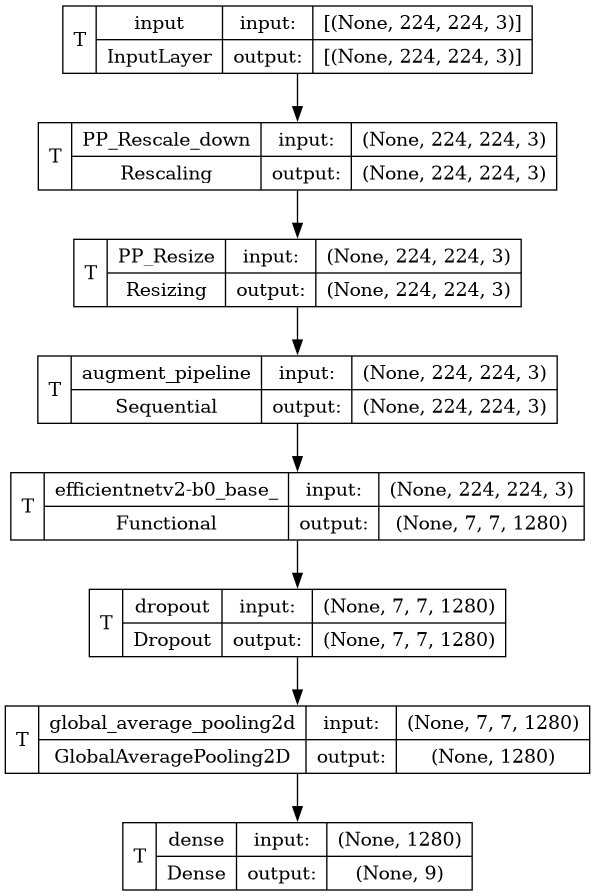

In [22]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [23]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(MODEL_NAME, save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

3
{'name': 'AdamW', 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 0.0002, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2026-02-16 08:10:23.891482: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-efficientnetv2-b0_base_/efficientnetv2-b0_base_/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1771229431.389798      69 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/329 [==============================] - ETA: 0s - loss: 0.1678 - accuracy: 0.6420

2026-02-16 08:11:36.177019: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-efficientnetv2-b0_base_/efficientnetv2-b0_base_/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 103s 165ms/step - loss: 0.1678 - accuracy: 0.6420 - val_loss: 0.0820 - val_accuracy: 0.7895 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 49s 147ms/step - loss: 0.0821 - accuracy: 0.7835 - val_loss: 0.0537 - val_accuracy: 0.8555 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 48s 147ms/step - loss: 0.0630 - accuracy: 0.8285 - val_loss: 0.0424 - val_accuracy: 0.8818 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 49s 147ms/step - loss: 0.0509 - accuracy: 0.8567 - val_loss: 0.0362 - val_accuracy: 0.8941 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 49s 147ms/step - loss: 0.0445 - accuracy: 0.8706 - val_loss: 0.0359 - val_accuracy: 0.8978 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 48s 147ms/step - loss: 0.0416 - accuracy: 0.8759 - val_loss: 0.0345 - val_accuracy: 0.8966 - lr: 2.0000e-04
Epoch 7/300
329/329 [============

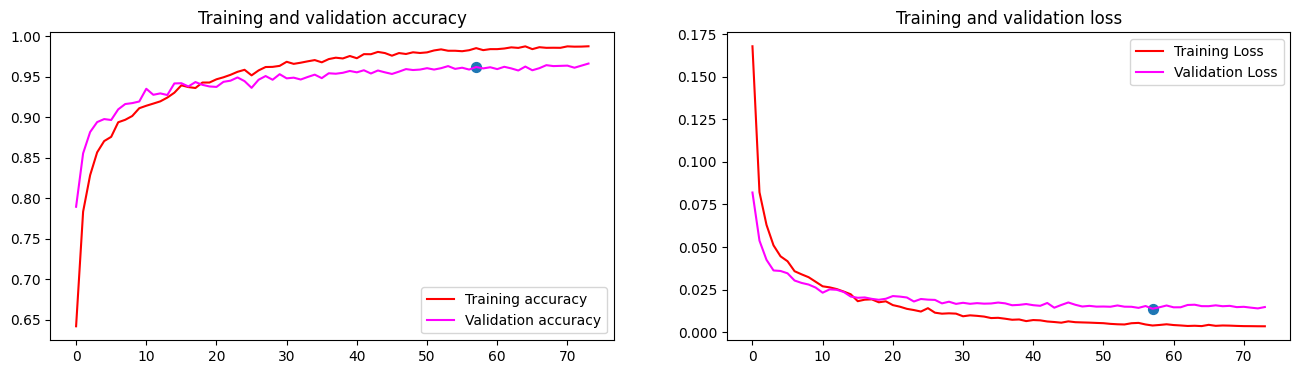

CPU times: user 1h 26min 3s, sys: 4min 50s, total: 1h 30min 53s
Wall time: 59min 28s


In [24]:
%%time
# Train the model
with strategy.scope():
    history1 = model.fit(
          train_generator,
          epochs=EPOCHS,
          validation_data=validation_generator,
          callbacks=callbacks,
        )

    # Plot training results
    plot_loss_acc(history1.history)

# Evaluation#1


Validation Set Statistics
model.evaluate
110/110 [==============================] - 4s 38ms/step - loss: 0.0147 - accuracy: 0.9597
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.89815   0.86222   0.87982       225
       Lantana    0.98544   0.95305   0.96897       213
   Parkinsonia    0.98049   0.97573   0.97810       206
    Parthenium    0.96618   0.98039   0.97324       204
Prickly acacia    0.93519   0.95283   0.94393       212
   Rubber vine    0.98485   0.96535   0.97500       202
     Siam weed    0.96226   0.94884   0.95550       215
    Snake weed    0.89552   0.88670   0.89109       203
      Negative    0.96850   0.97859   0.97352      1822

      accuracy                        0.96002      3502
     macro avg    0.95295   0.94486   0.94880      3502
  weighted avg    0.95989   0.96002   0.95989      3502


                False Positive Rate  Accuracy
Chinee apple               0.006713  0.862222
Lantana                    0.000912  0.953052
Parkinsonia                0.001214  0.975728
Parthenium                 0.002122  0.980392
Prickly acacia    

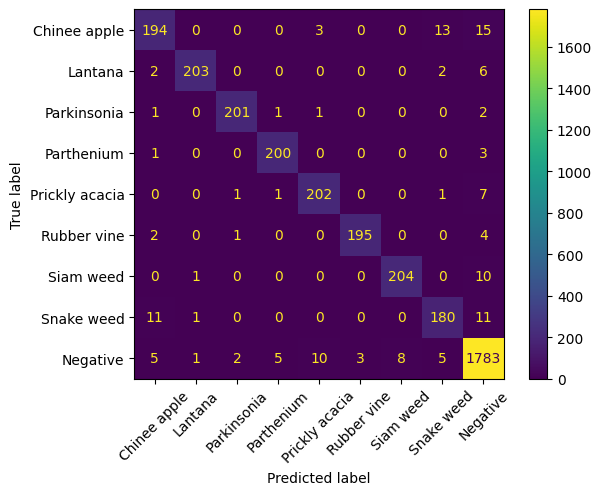


Testn Set Statistics
model.evaluate
110/110 [==============================] - 5s 41ms/step - loss: 0.6209 - accuracy: 0.5053
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.19565   0.08000   0.11356       225
       Lantana    0.26667   0.03756   0.06584       213
   Parkinsonia    0.47368   0.04369   0.08000       206
    Parthenium    0.17391   0.03902   0.06375       205
Prickly acacia    0.20513   0.03756   0.06349       213
   Rubber vine    0.24138   0.03465   0.06061       202
     Siam weed    0.31579   0.05581   0.09486       215
    Snake weed    0.18750   0.05911   0.08989       203
      Negative    0.53306   0.92092   0.67526      1821

      accuracy                        0.50214      3503
     macro avg    0.28809   0.14537   0.14525      3503
  weighted avg    0.40056   0.50214   0.38915      3503


                False Positive Rate  Accuracy
Chinee apple               0.022575  0.080000
Lantana                    0.006687  0.037559
Parkinsonia                0.003033  0.043689
Parthenium                 0.011522  0.039024
Prickly acacia    

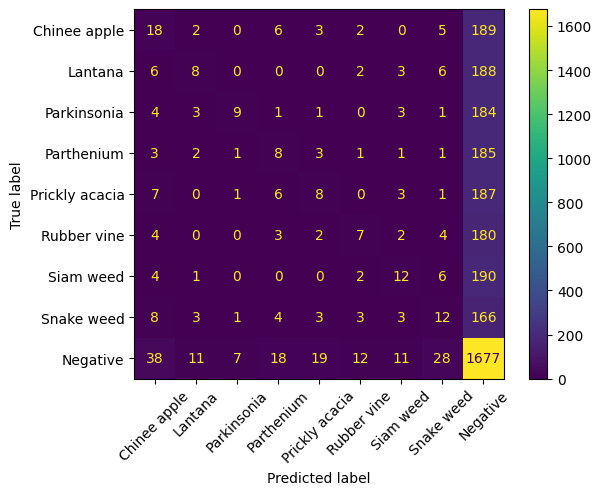

In [25]:
print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

# Freezing Base Model

In [26]:
with strategy.scope():
    for layer in model.layers:
        name = layer.name.lower()
        if 'base' in name:
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer efficientnetv2-b0_base_ True


# Evaluations #1.1b

Test After Freezing
Train Set Statistics
model.evaluate
329/329 [==============================] - 13s 38ms/step - loss: 0.0013 - accuracy: 0.9958
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99116   0.99556   0.99336       676
       Lantana    0.99685   0.99372   0.99528       637
   Parkinsonia    0.99518   1.00000   0.99758       619
    Parthenium    0.99513   1.00000   0.99756       613
Prickly acacia    1.00000   0.98587   0.99289       637
   Rubber vine    0.99669   0.99669   0.99669       605
     Siam weed    0.99690   1.00000   0.99845       644
    Snake weed    0.99345   0.99508   0.99427       610
      Negative    0.99762   0.99744   0.99753      5463

      accuracy                        0.99667     10504
     macro avg    0.99589   0.99604   0.99596     10504
  weighted avg    0.99667   0.99667   0.99667     10504


                False Positive Rate  Accuracy
Chinee apple               0.000611  0.995562
Lantana                    0.000203  0.993721
Parkinsonia                0.000303  1.000000
Parthenium                 0.000303  1.000000
Prickly acacia    

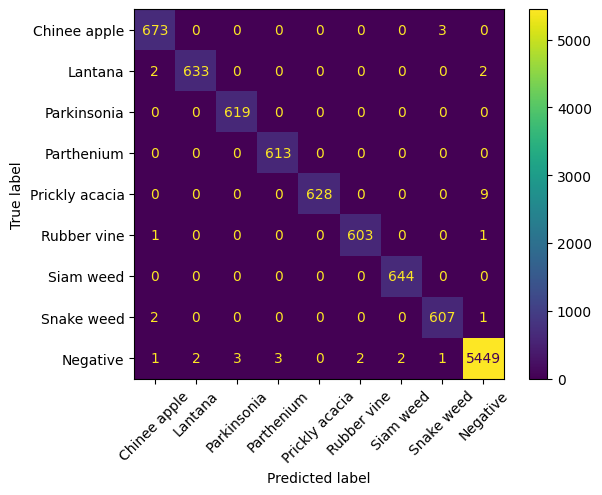

Validation Set Stats
model.evaluate
110/110 [==============================] - 4s 38ms/step - loss: 0.0137 - accuracy: 0.9609
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93023   0.88889   0.90909       225
       Lantana    0.99005   0.93427   0.96135       213
   Parkinsonia    0.98077   0.99029   0.98551       206
    Parthenium    0.97073   0.97549   0.97311       204
Prickly acacia    0.93868   0.93868   0.93868       212
   Rubber vine    0.97561   0.99010   0.98280       202
     Siam weed    0.96313   0.97209   0.96759       215
    Snake weed    0.87324   0.91626   0.89423       203
      Negative    0.97755   0.97969   0.97862      1822

      accuracy                        0.96545      3502
     macro avg    0.95555   0.95397   0.95455      3502
  weighted avg    0.96566   0.96545   0.96544      3502


                False Positive Rate  Accuracy
Chinee apple               0.004577  0.888889
Lantana                    0.000608  0.934272
Parkinsonia                0.001214  0.990291
Parthenium                 0.001819  0.975490
Prickly acacia    

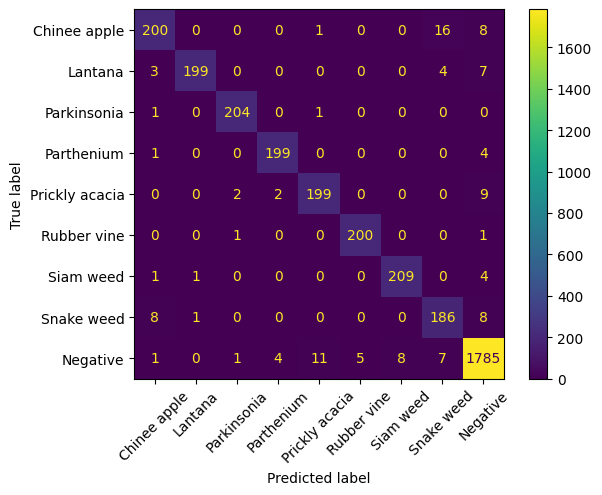

Test Set Stats
model.evaluate
110/110 [==============================] - 5s 39ms/step - loss: 0.6195 - accuracy: 0.5013
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.72281   0.91556   0.80784       225
       Lantana    0.93651   0.83099   0.88060       213
   Parkinsonia    0.95098   0.94175   0.94634       206
    Parthenium    0.79365   0.97561   0.87527       205
Prickly acacia    0.92991   0.93427   0.93208       213
   Rubber vine    0.94022   0.85644   0.89637       202
     Siam weed    0.77860   0.98140   0.86831       215
    Snake weed    0.77830   0.81281   0.79518       203
      Negative    0.97754   0.90829   0.94165      1821

      accuracy                        0.90751      3503
     macro avg    0.86761   0.90634   0.88263      3503
  weighted avg    0.91756   0.90751   0.90955      3503


                False Positive Rate  Accuracy
Chinee apple               0.024100  0.915556
Lantana                    0.003647  0.830986
Parkinsonia                0.003033  0.941748
Parthenium                 0.015767  0.975610
Prickly acacia    

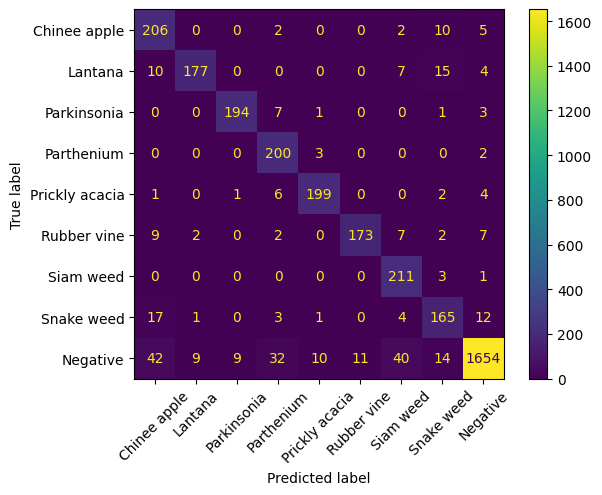

In [27]:
## Test After Freezing
print("Test After Freezing")

print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.50605   0.92889   0.65517       225
       Lantana    0.82488   0.84038   0.83256       213
   Parkinsonia    0.94581   0.93204   0.93888       206
    Parthenium    0.78800   0.96098   0.86593       205
Prickly acacia    0.84388   0.93897   0.88889       213
   Rubber vine    0.92090   0.80693   0.86016       202
     Siam weed    0.75089   0.98140   0.85081       215
    Snake weed    0.77465   0.81281   0.79327       203
      Negative    0.97950   0.81329   0.88869      1821

      accuracy                        0.85555      3503
     macro avg    0.81495   0.89063   0.84159      3503
  weighted avg    0.88897   0.85555   0.86241      3503


                False Positive Rate  Accuracy
Chinee apple               0.062233  0.928889
Lantana                    0.011550  0.840376
Parkinsonia                0.003336  0.932039
Parthenium                 0.016070  0.960976
Prickly acacia    

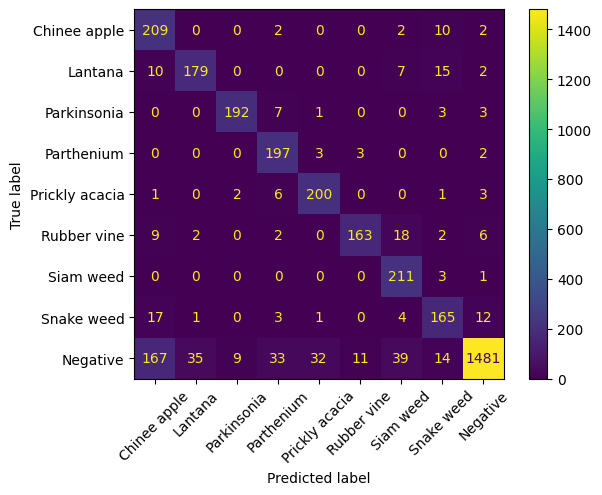

In [28]:
printStats(a,b,0.11)

# Trial 2

In [29]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=2.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
  
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'AdamW', 'weight_decay': 0.005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 2e-05, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/60


2026-02-16 09:16:04.567593: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-efficientnetv2-b0_base_/efficientnetv2-b0_base_/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 28s 61ms/step - loss: 0.0908 - accuracy: 0.7756 - val_loss: 0.0386 - val_accuracy: 0.9001 - lr: 2.0000e-05
Epoch 2/60
329/329 [==============================] - 18s 55ms/step - loss: 0.0823 - accuracy: 0.7927 - val_loss: 0.0383 - val_accuracy: 0.9006 - lr: 2.0000e-05
Epoch 3/60
329/329 [==============================] - 18s 55ms/step - loss: 0.0765 - accuracy: 0.8035 - val_loss: 0.0356 - val_accuracy: 0.9023 - lr: 2.0000e-05
Epoch 4/60
329/329 [==============================] - 18s 54ms/step - loss: 0.0748 - accuracy: 0.8058 - val_loss: 0.0377 - val_accuracy: 0.8989 - lr: 2.0000e-05
Epoch 5/60
329/329 [==============================] - 18s 54ms/step - loss: 0.0709 - accuracy: 0.8126 - val_loss: 0.0369 - val_accuracy: 0.8989 - lr: 2.0000e-05
Epoch 6/60
328/329 [============================>.] - ETA: 0s - loss: 0.0687 - accuracy: 0.8209
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.5999999595806004e-05.
329/329 [========================

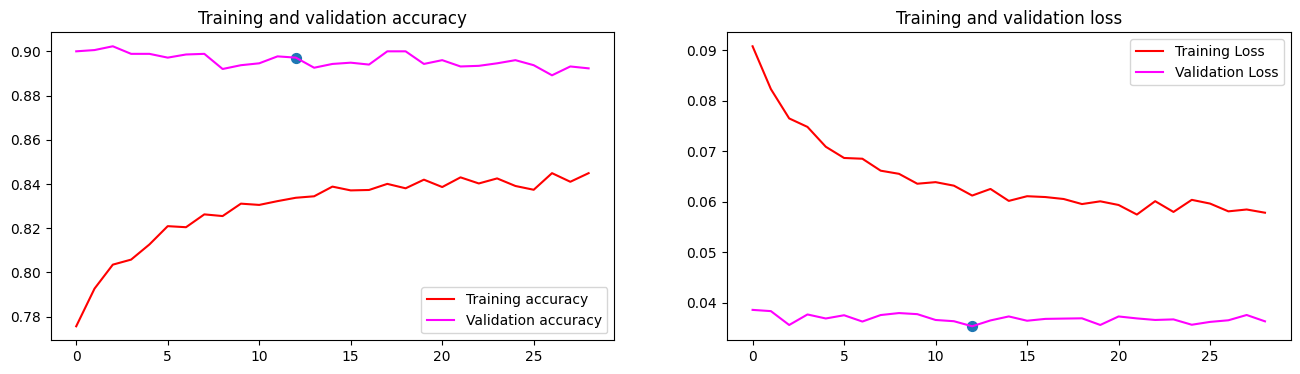

In [30]:
# Train the model

with strategy.scope():
    history2 = model.fit(
          train_generator,
          epochs=EPOCHS//5,
          validation_data=validation_generator,
          callbacks=[early_stopping,reduce_lr]
        )

print("Saving the Checkpoint")
model.save("At10tion-"+MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)

# Accuracy / Loss Plots

Total Epochs: range(0, 103)


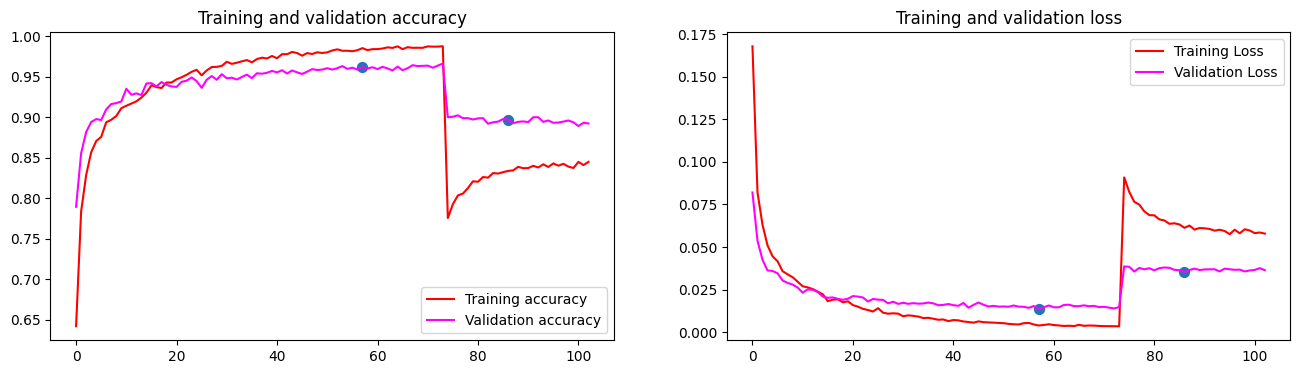

In [31]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 74)


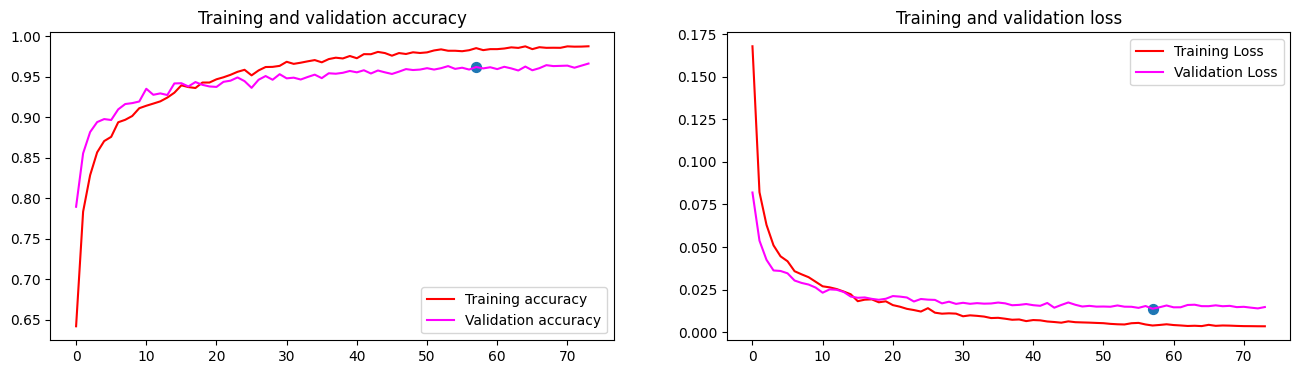

Total Epochs: range(0, 29)


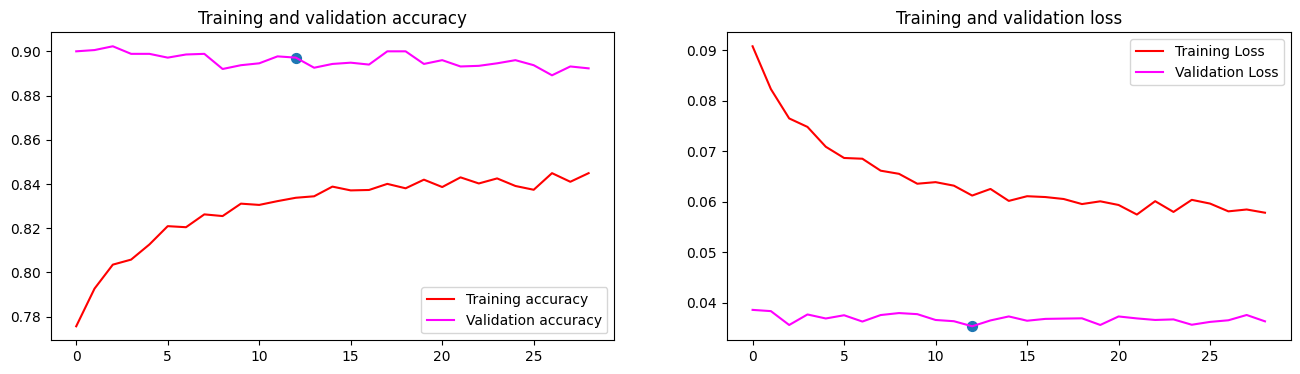

In [32]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 11s 32ms/step - loss: 0.0181 - accuracy: 0.9400
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.80518   0.96598   0.87828       676
       Lantana    0.95928   0.92465   0.94165       637
   Parkinsonia    0.90735   0.99677   0.94996       619
    Parthenium    0.91074   0.98206   0.94505       613
Prickly acacia    0.98720   0.96860   0.97781       637
   Rubber vine    0.91705   0.98678   0.95064       605
     Siam weed    0.83289   0.98292   0.90171       644
    Snake weed    0.82961   0.97377   0.89593       610
      Negative    0.99539   0.90848   0.94995      5463

      accuracy                        0.93917     10504
     macro avg    0.90497   0.96555   0.93233     10504
  weighted avg    0.94623   0.93917   0.94018     10504


                False Positive Rate  Accuracy
Chinee apple               0.016077  0.965976
Lantana                    0.002534  0.924647
Parkinsonia                0.006373  0.996769
Parthenium                 0.005965  0.982055
Prickly acacia    

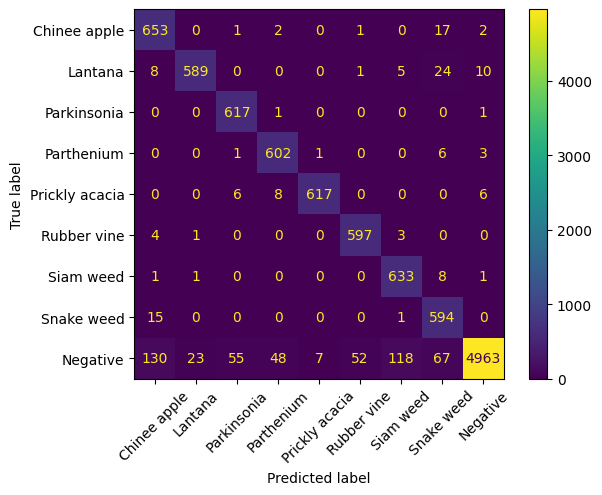


Validation Set Statistics
model.evaluate
110/110 [==============================] - 4s 32ms/step - loss: 0.0357 - accuracy: 0.8955
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.75191   0.87556   0.80903       225
       Lantana    0.91667   0.82629   0.86914       213
   Parkinsonia    0.87446   0.98058   0.92449       206
    Parthenium    0.83544   0.97059   0.89796       204
Prickly acacia    0.91121   0.91981   0.91549       212
   Rubber vine    0.88426   0.94554   0.91388       202
     Siam weed    0.76316   0.94419   0.84407       215
    Snake weed    0.69202   0.89655   0.78112       203
      Negative    0.98211   0.87377   0.92477      1822

      accuracy                        0.89549      3502
     macro avg    0.84569   0.91476   0.87555      3502
  weighted avg    0.90827   0.89549   0.89790      3502


                False Positive Rate  Accuracy
Chinee apple               0.019835  0.875556
Lantana                    0.004865  0.826291
Parkinsonia                0.008799  0.980583
Parthenium                 0.011825  0.970588
Prickly acacia    

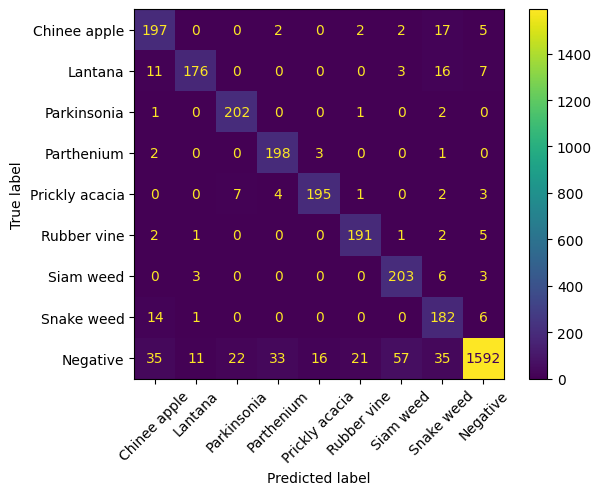


Testn Set Statistics
model.evaluate
110/110 [==============================] - 4s 33ms/step - loss: 0.0335 - accuracy: 0.9029
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.77907   0.89333   0.83230       225
       Lantana    0.95939   0.88732   0.92195       213
   Parkinsonia    0.87179   0.99029   0.92727       206
    Parthenium    0.85463   0.94634   0.89815       205
Prickly acacia    0.93396   0.92958   0.93176       213
   Rubber vine    0.86283   0.96535   0.91121       202
     Siam weed    0.76404   0.94884   0.84647       215
    Snake weed    0.72984   0.89163   0.80266       203
      Negative    0.98654   0.88523   0.93314      1821

      accuracy                        0.90722      3503
     macro avg    0.86023   0.92643   0.88944      3503
  weighted avg    0.91823   0.90722   0.90936      3503


                False Positive Rate  Accuracy
Chinee apple               0.017389  0.893333
Lantana                    0.002432  0.887324
Parkinsonia                0.009099  0.990291
Parthenium                 0.010006  0.946341
Prickly acacia    

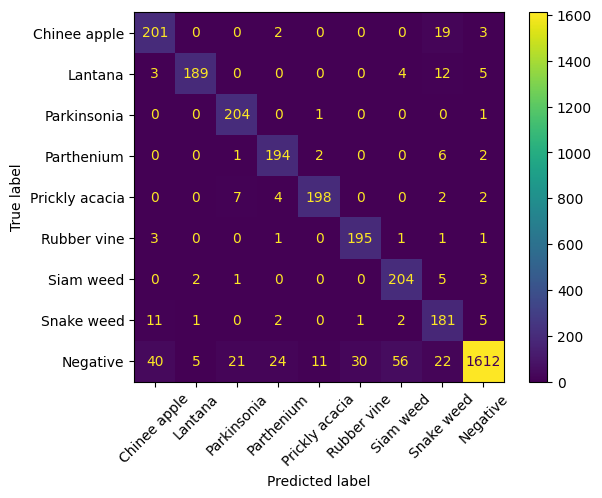

In [33]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.51928   0.89778   0.65798       225
       Lantana    0.82759   0.90141   0.86292       213
   Parkinsonia    0.87446   0.98058   0.92449       206
    Parthenium    0.84956   0.93659   0.89095       205
Prickly acacia    0.84746   0.93897   0.89087       213
   Rubber vine    0.85000   0.92574   0.88626       202
     Siam weed    0.73381   0.94884   0.82759       215
    Snake weed    0.71825   0.89163   0.79560       203
      Negative    0.99027   0.78254   0.87423      1821

      accuracy                        0.85213      3503
     macro avg    0.80119   0.91156   0.84565      3503
  weighted avg    0.88681   0.85213   0.85787      3503


                False Positive Rate  Accuracy
Chinee apple               0.057047  0.897778
Lantana                    0.012158  0.901408
Parkinsonia                0.008796  0.980583
Parthenium                 0.010309  0.936585
Prickly acacia    

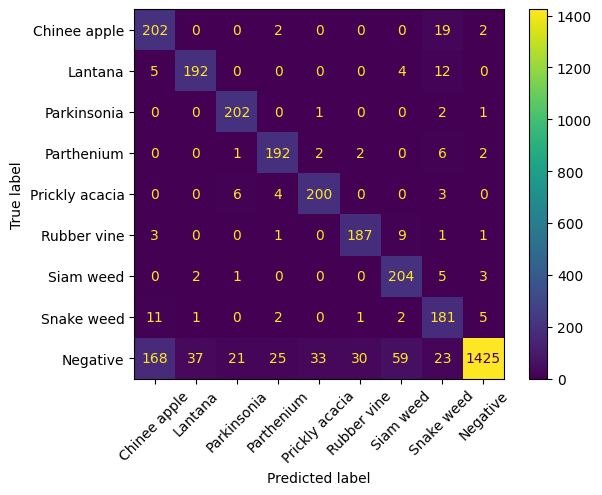

In [34]:
printStats(a,b,0.11)

## Clear Files

In [35]:
shutil.rmtree(base_dir)